<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/code/basicGAN/basicGAN_20_steps_SV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [1]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [3]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import time

import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [4]:
from utils.tools import *

data = pd.read_table('./data/trips_SV_2008_10_min.csv', sep = ',')
data['datetime'] = pd.to_datetime(data['datetime'], format='%Y-%m-%d %H:%M:%S')

colony = (-77.264, -11.773)
# colony =  (-32.392, -3.819)
data = format_data(data, colony, 5e4)
data = data[data.dist_colony > 1000]

padding = 20
traj = padding_data(data, padding)

In [5]:
class TrajDataSet(Dataset):
    def __init__(self,  traj, transform=None):
        self.traj = traj
        self.transform = transform

    def __len__(self):
        return self.traj.shape[0]

    def __getitem__(self, idx):
        
        # select coordinates
        sample = self.traj[idx,:,:]

        if self.transform:
            sample = self.transform(sample)

        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [6]:
# hyperparameters
batch_size = 39

## reduce size dataset
train_set = TrajDataSet(traj, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=False)

In [7]:
x =  next(iter(train_loader))

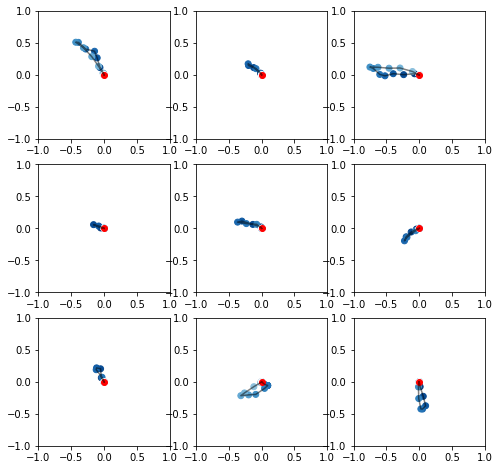

In [8]:
plt.figure(figsize = (8,8))
i = 4

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(x.numpy()[i,0,:], x.numpy()[i,1,:], c = 'black', alpha = 0.5)
    plt.scatter(x.numpy()[i,0,:], x.numpy()[i,1,:], c=np.arange(padding), cmap='Blues_r')
    plt.scatter(0,0, c = 'red')
    plt.xlim(-1,1)
    plt.ylim(-1,1)


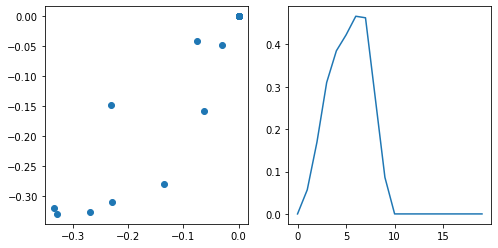

In [9]:
plt.figure(figsize = (8,4))

x = traj[0,0,:]
y = traj[0,1,:]

plt.subplot(1,2, 1)
plt.scatter(x, y)

plt.subplot(1,2, 2)
plt.plot(np.sqrt(x**2 + y**2))

## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [10]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

## CNN

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
class CNNGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(    
            nn.ConvTranspose1d(20, 10, kernel_size = 5, stride = 2, padding = 0, bias = False),
            nn.BatchNorm1d(10),
            nn.ReLU(True),

            nn.ConvTranspose1d(10, 5, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(5),
            nn.ReLU(True),

            nn.ConvTranspose1d(5, 2, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.Tanh()
         )
        

    def forward(self, z, batch_size):    
        out = self.cnn(z)
        return out

In [13]:
gen = CNNGenerator().to(device)
z = torch.rand((batch_size, padding, 1)).to(device) # (batch, seq, feature)

out = gen(z, batch_size)
out.shape

torch.Size([39, 2, 20])

In [14]:
class CNNDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.cnn = nn.Sequential(
            
            nn.Conv1d(2, 5, kernel_size = 5, stride = 1, padding = 2, bias = False),
            nn.BatchNorm1d(5),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(5, 10, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(10),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(10, 20, kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(20),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(20, 1, kernel_size=5, stride=2, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x, batch_size):

        out = self.cnn(x)

        return out.squeeze(1)


In [15]:
dis = CNNDiscriminator().to(device)
dis(out, batch_size).shape

torch.Size([39, 1])

In [16]:
sum(p.numel() for p in gen.parameters())

1270

# LSTM

In [17]:
class LSTMGenerator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(1, 16, 1, batch_first=True, bias = True)
        self.linear = nn.Sequential(
                        nn.ReLU(),
                        nn.Linear(16, 16),
                        nn.ReLU(),
                        nn.Linear(16, 2),
                        nn.Tanh()
                      )

    def forward(self, x, batch_size):  

        h_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #hidden state
        c_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #hidden state

        # init LSTM cells  (batch, seq, feature)
        out, h_n = self.lstm(x, (h_0, c_0))
        out = self.linear(out)
        out = out.view(batch_size, 2, padding)
        return torch.cumsum(out, 2)

In [18]:
gen = LSTMGenerator().to(device)
z = torch.rand((batch_size, padding, 1)).to(device) # (batch, seq, feature)

out = gen(z, batch_size)
out.shape

torch.Size([39, 2, 20])

In [19]:
sum(p.numel() for p in gen.parameters())

1522

In [20]:
class LSTMDiscriminator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(2, 16, 1, batch_first=True)
        
        self.linear = nn.Sequential(
                        nn.Linear(16, 16),
                        nn.ReLU(),
                        nn.Linear(16, 1),
                        nn.Tanh()
                      )

    def forward(self, x, batch_size):  

        h_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #hidden state
        c_0 = torch.autograd.Variable(torch.randn(1, batch_size, 16)).to(device) #internal stat

        # init LSTM cells  (batch, seq, feature)
        out = x.view(batch_size, padding, 2)
        out, (h_n, c_n) = self.lstm(out, (h_0, c_0))
        out = self.linear(out)
        out = 1/(1 + torch.exp(-torch.mean(out, 1)))

        return out

In [21]:
dis = LSTMDiscriminator().to(device)
dis(out, batch_size).shape

torch.Size([39, 1])

In [38]:
class GAN :
  """
  This class creates a GAN with: 
   - a Generator network 
   - a Discriminator network
   - a Dataloader object from pytorch
  """
  def __init__(self, generator, discriminator, train_loader, device):
    self.generator = generator.to(device)
    self.discriminator = discriminator.to(device)
    self.device = device
    self.train_loader = train_loader
    
  def train(self, nb_epoch, lr, device):
    """
    This function trains the GAN for nb_epoch with a fiwed learning rate lr
    """                                                       
    criterion = nn.BCELoss()
    optim_d = optim.Adam(discriminator.parameters(), lr= lr, betas=(0.5, 0.999))
    optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))
    score = []

    time_start = time.perf_counter()
    for epoch in range(nb_epoch):
        i = 0

        loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
        for _, x in enumerate(self.train_loader):

            batch = x.shape[0]
            
            target_ones = torch.ones((batch, 1), device=self.device)
            target_zeros = torch.zeros((batch, 1), device=self.device)
            
            i+= 1
            #### TRAIN DISCRIMINATOR
            ## true samples
            x = x.to(device)

            self.discriminator.zero_grad()
            pred_real = self.discriminator(x, batch)
            loss_real = criterion(pred_real, target_ones)

            ## false samples
            seq_length =  x.shape[2]
            z = torch.rand((batch, seq_length, 1), device=self.device)
            with torch.no_grad():
                fake_samples = self.generator(z, batch)
            pred_fake = self.discriminator(fake_samples, batch)
            loss_fake = criterion(pred_fake, target_zeros)
            
            # combine
            loss = (loss_real + loss_fake) / 2
            loss.backward()
            optim_d.step()

            loss_d_real_running += loss_real.item()
            loss_d_fake_running += loss_fake.item()
            
            #### TRAIN GENERATOR
            self.generator.zero_grad()
            z = torch.rand((batch, seq_length, 1), device=self.device) 

            generated = self.generator(z, batch)
            classifications = self.discriminator(generated, batch)
            loss = criterion(classifications, target_ones) #+ 0.1 * torch.sum((generated[:,0, 0] - generated[:,0,-1])**2)
            loss.backward()
            optim_g.step()

            loss_g_running += loss.item()

        if epoch%100 == 0:
          traj_sim = self.test(100)
          score.append(get_score(traj, traj_sim))
       
        if epoch%500 == 0:
          print('Epoch [{}/{}] -----------------------------------------------------------------------------'
              .format(epoch+1, nb_epoch, i, len(self.train_loader)))
          print('G: {}, Dr : {}, Df : {}'
              .format(loss_g_running/batch, loss_d_real_running/batch, loss_d_fake_running/batch))
          
          self.plot()


    #run your code
    self.score = score
    self.computation_time = (time.perf_counter() - time_start)

  def test(self, nb):
    """
    This function generates nb trajectories
    """ 
    self.generator.zero_grad()    

    x =  next(iter(self.train_loader))
    seq_length = x.shape[2]

    z = torch.rand((nb, seq_length, 1), device=self.device)
    generated = self.generator(z, nb)
    traj_sim = generated.cpu().detach().numpy()
    return traj_sim

  def plot(self):
    """
    This function plots few trajectories
    """ 
    traj_sim = self.test(16)

    plt.figure(figsize = (8,8))
    for i in range(16):
      plt.subplot(4,4,i+1)
      plt.plot(traj_sim[i,0,:], traj_sim[i,1,:], c = 'black', alpha = 0.5)
      plt.scatter(traj_sim[i,0,:], traj_sim[i,1,:], c=np.arange(traj_sim.shape[2]), cmap='Blues_r')
      plt.scatter(0,0, c = 'red')
      plt.xlim(-1,1)
      plt.ylim(-1,1)

    plt.show()
    plt.close()

  def save(self, name):
    torch.save(self.generator, name+'_G.pt')
    torch.save(self.discriminator, name+'_D.pt')

In [39]:
def weights_init(m):
    """
    This function initializes the model weights randomly from a 
    Normal distribution. This follows the specification from the DCGAN paper.
    https://arxiv.org/pdf/1511.06434.pdf
    Source: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# CNN - CNN

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.038355558346479364, Dr : 0.03780251588576879, Df : 0.03380809686122797


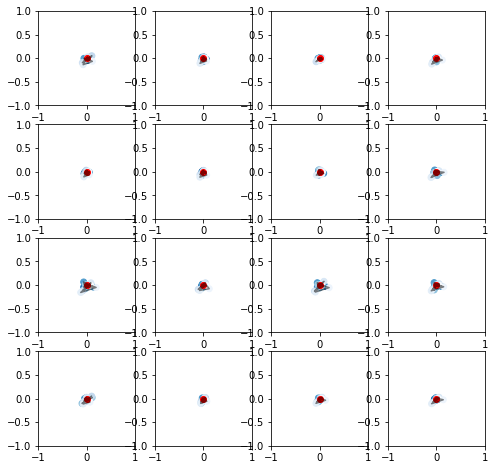

Epoch [501/5000] -----------------------------------------------------------------------------
G: 0.11594132276681754, Dr : 0.017789382200974684, Df : 0.013354805799630972


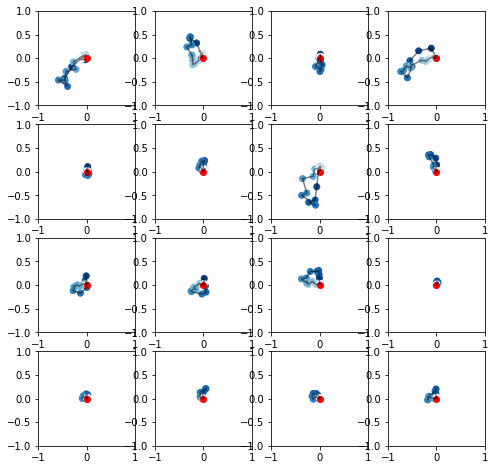

KeyboardInterrupt: ignored

In [40]:
generator = CNNGenerator()
discriminator = CNNDiscriminator()

### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

cnn_cnn = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

cnn_cnn.train(nb_epoch, lr, device)

# LSTM - LSTM


Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.038472074728745684, Dr : 0.03831365933785072, Df : 0.03278303299194727


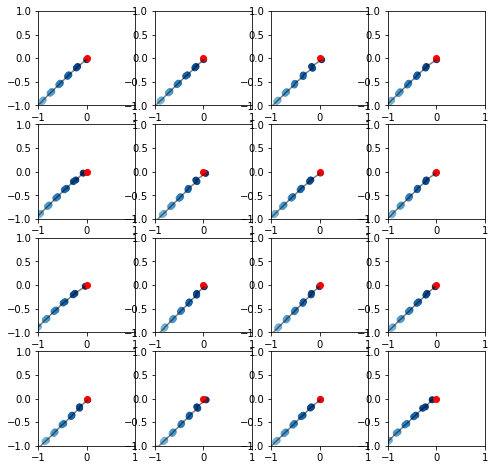

Epoch [501/5000] -----------------------------------------------------------------------------
G: 0.035916128219702304, Dr : 0.03587196576289642, Df : 0.03518384542220678


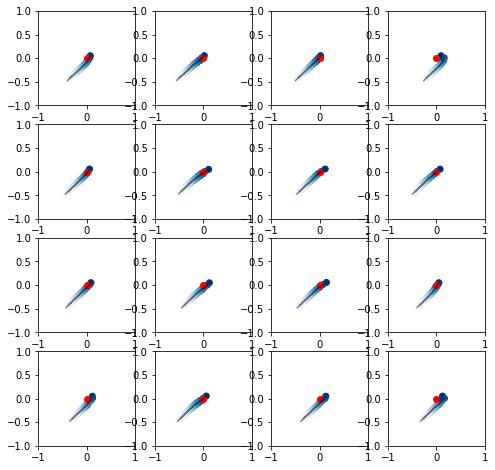

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 0.03585549348439926, Dr : 0.03588419082837227, Df : 0.035240581402411826


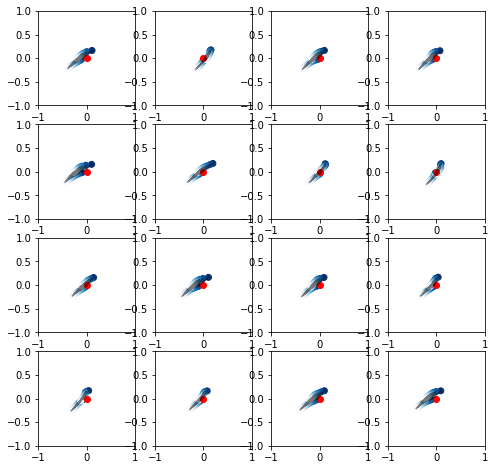

Epoch [1501/5000] -----------------------------------------------------------------------------
G: 0.03578242124655308, Dr : 0.03569602813476171, Df : 0.03532317968515249


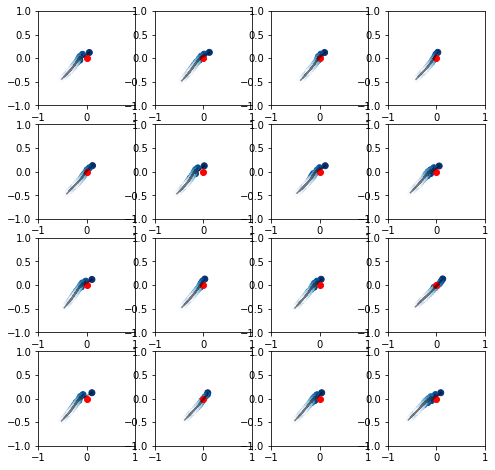

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 0.03555066004777566, Dr : 0.035575704696850896, Df : 0.03551956170644516


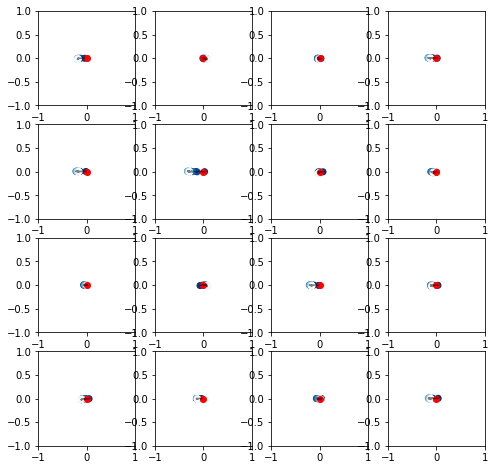

Epoch [2501/5000] -----------------------------------------------------------------------------
G: 0.03557368272390121, Dr : 0.03560140346869444, Df : 0.03553055647091988


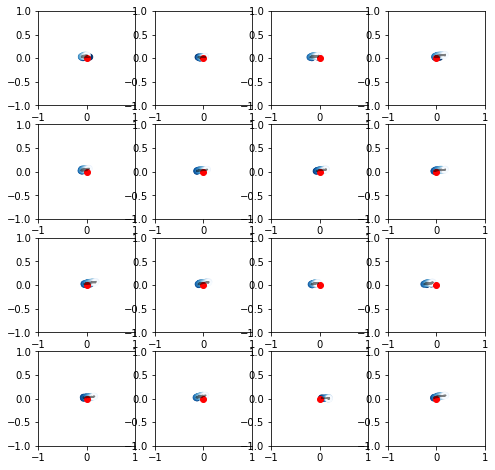

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 0.03551706289633726, Dr : 0.035487693089705244, Df : 0.035576024116613925


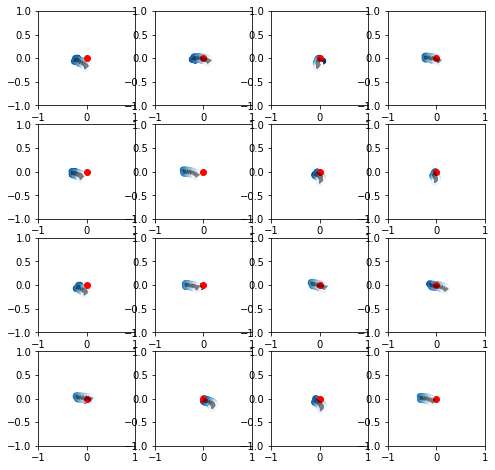

Epoch [3501/5000] -----------------------------------------------------------------------------
G: 0.03556122229649471, Dr : 0.035582345265608564, Df : 0.035544346540402144


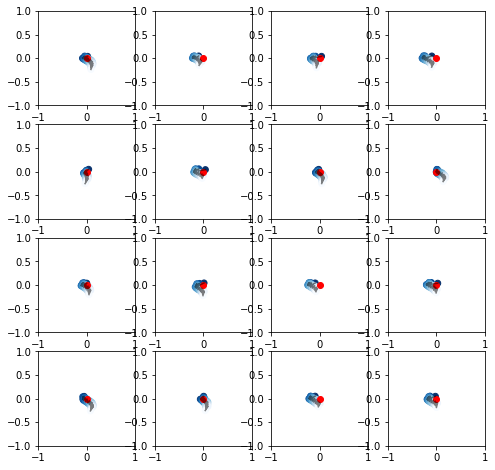

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 0.035637678244175054, Dr : 0.035631696383158364, Df : 0.035500731223668806


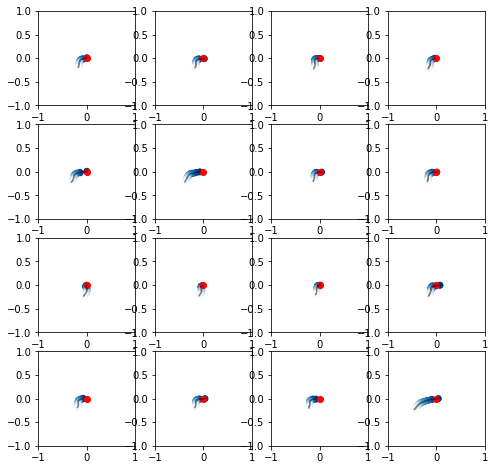

Epoch [4501/5000] -----------------------------------------------------------------------------
G: 0.0355146756538978, Dr : 0.03547493769572331, Df : 0.035572403516524874


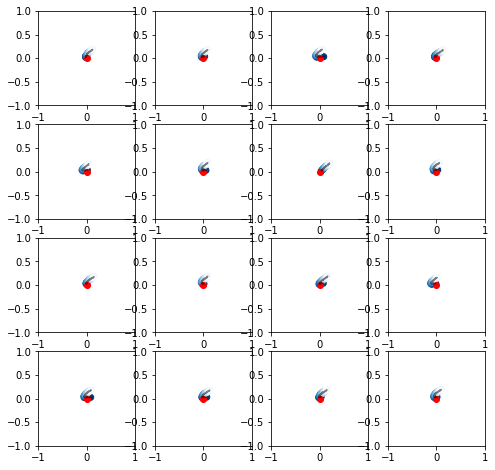

In [25]:
generator = LSTMGenerator().to(device)
discriminator = LSTMDiscriminator().to(device)

# ### WEIGHT INITIALIZATION
# generator.apply(weights_init)
# discriminator.apply(weights_init)

lstm_lstm = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

lstm_lstm.train(nb_epoch, lr, device)

# LSTM - CNN

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.03472785613475702, Dr : 0.036995465938861556, Df : 0.03748617111108242


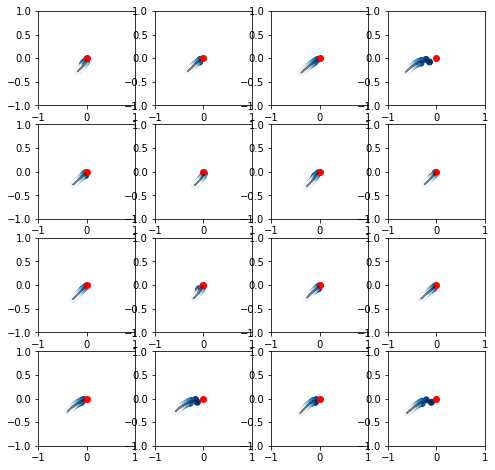

Epoch [501/5000] -----------------------------------------------------------------------------
G: 0.2699917157491048, Dr : 0.000388652778779849, Df : 0.0003050547093153


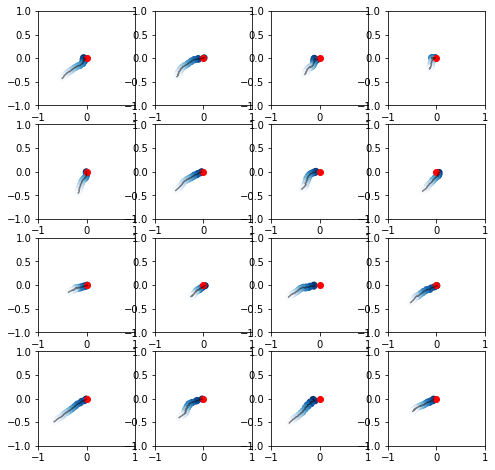

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 0.32421180529472154, Dr : 7.945470786534059e-05, Df : 0.00011155390156767308


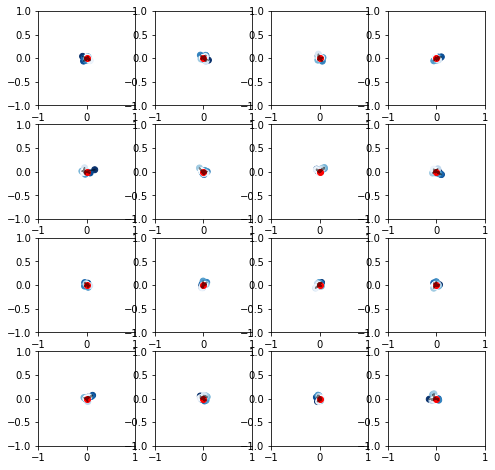

Epoch [1501/5000] -----------------------------------------------------------------------------
G: 0.38314115084134615, Dr : 4.925357494264459e-05, Df : 7.487992302347452e-05


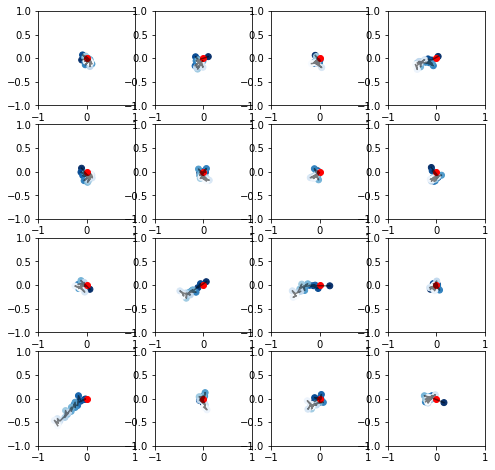

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 0.43134547502566606, Dr : 1.4477498972645173e-05, Df : 1.616855838503211e-05


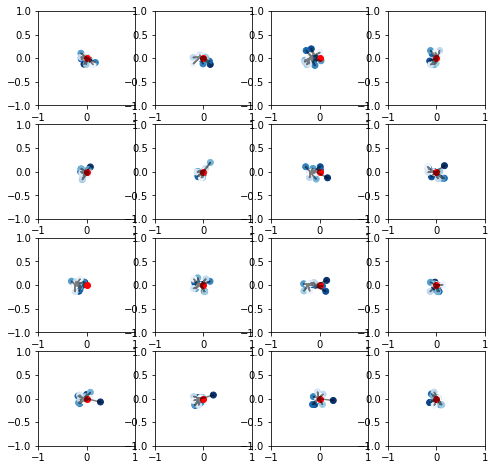

Epoch [2501/5000] -----------------------------------------------------------------------------
G: 0.4666271698780549, Dr : 6.418639737276886e-06, Df : 7.10038129443255e-06


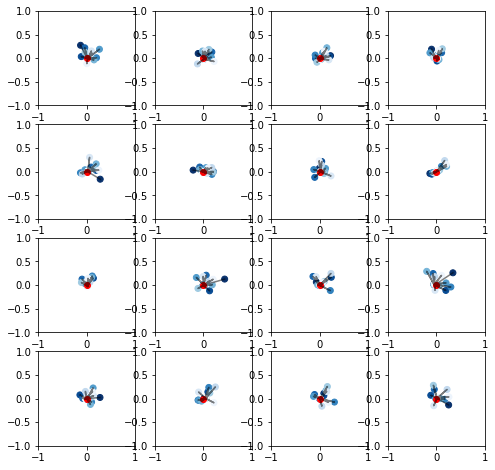

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 0.4939683522933569, Dr : 3.5561440596118187e-06, Df : 7.161201210692525e-06


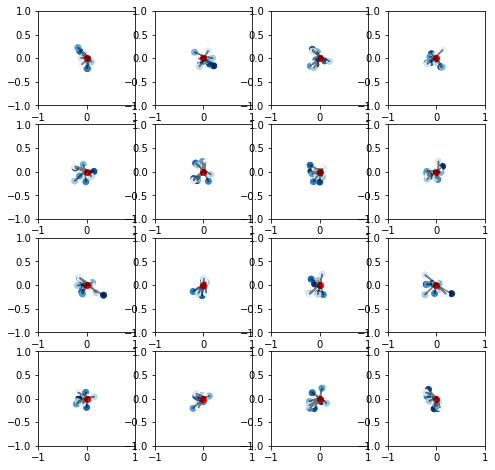

Epoch [3501/5000] -----------------------------------------------------------------------------
G: 0.5360043354523487, Dr : 2.440116170477361e-06, Df : 2.4273033956817994e-06


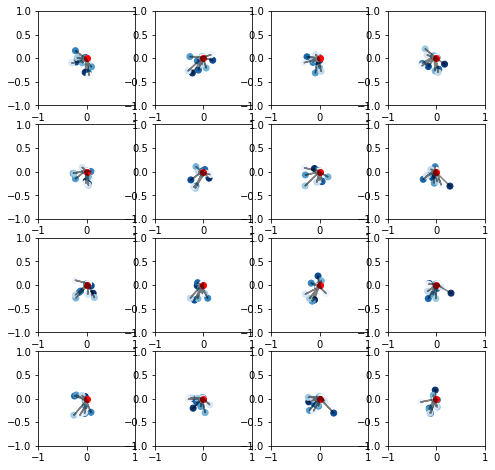

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 0.4102499179351024, Dr : 0.0001290740015415045, Df : 0.0002245637737453366


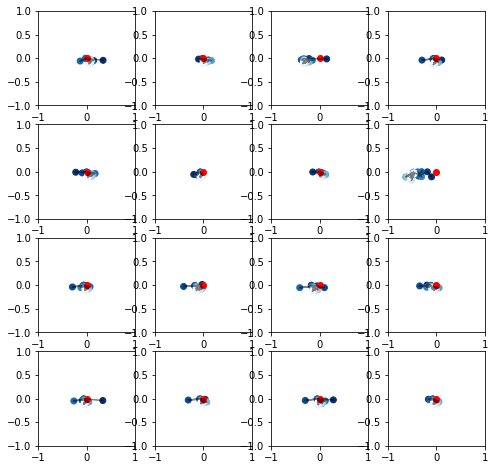

Epoch [4501/5000] -----------------------------------------------------------------------------
G: 0.4698122709225386, Dr : 3.7734153850648836e-05, Df : 1.0133247437457052e-05


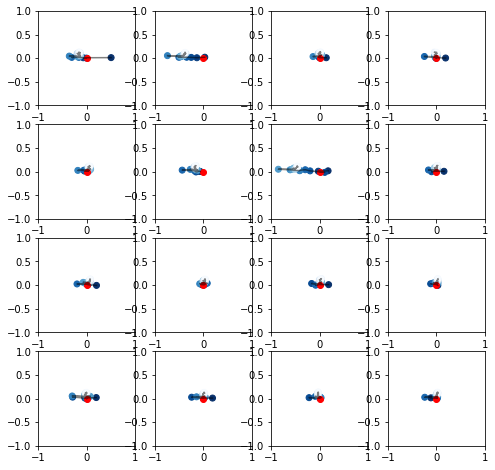

In [26]:
generator = LSTMGenerator().to(device)
discriminator = CNNDiscriminator().to(device)

### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

lstm_cnn = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

lstm_cnn.train(nb_epoch, lr, device)

# CNN - LSTM

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.03462195854920607, Dr : 0.034598326071714744, Df : 0.03651968638102213


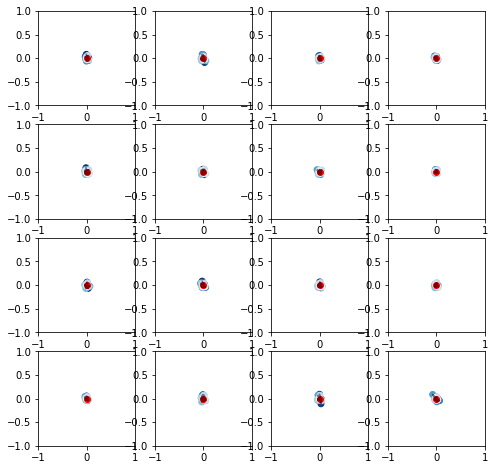

Epoch [501/5000] -----------------------------------------------------------------------------
G: 0.03548212846120199, Dr : 0.03553190139623789, Df : 0.03558636628664457


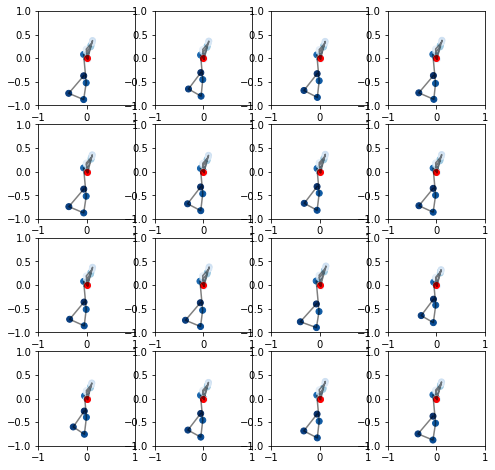

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 0.03551345910781469, Dr : 0.035518941206809804, Df : 0.03556756331370427


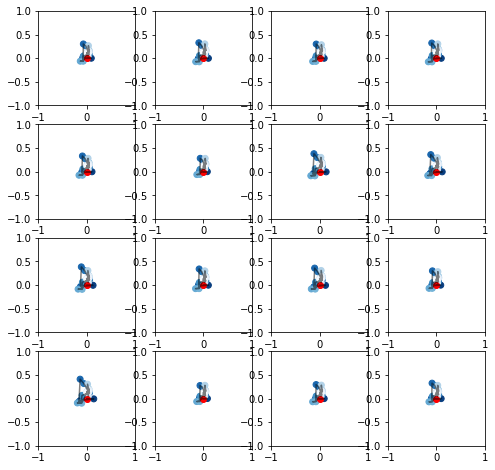

Epoch [1501/5000] -----------------------------------------------------------------------------
G: 0.03552556802064945, Dr : 0.0355525077917637, Df : 0.035511828385866605


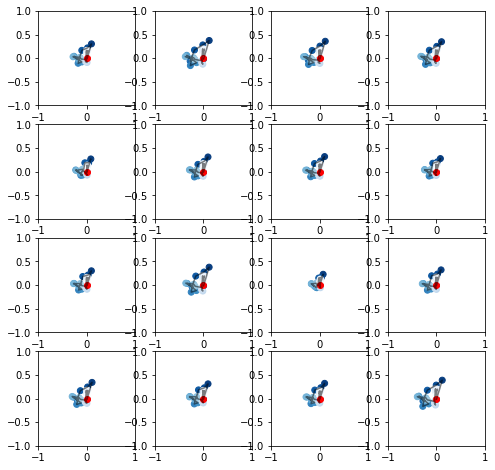

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 0.03556778186406845, Dr : 0.035592062351031184, Df : 0.03553699682920407


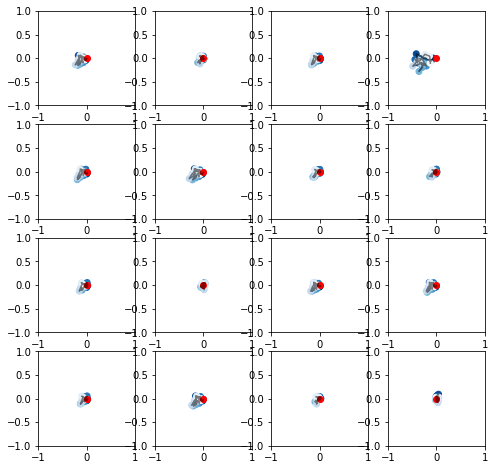

Epoch [2501/5000] -----------------------------------------------------------------------------
G: 0.035515132622841075, Dr : 0.03553637021627182, Df : 0.035539304598783836


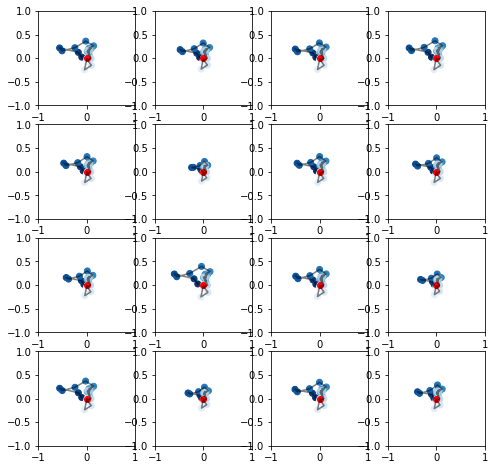

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 0.035573577269529685, Dr : 0.03556244189922626, Df : 0.03553033944887993


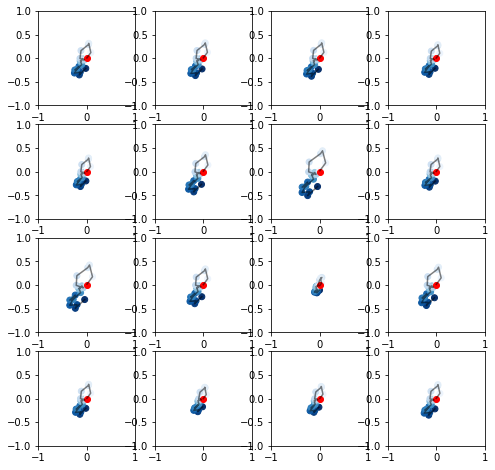

Epoch [3501/5000] -----------------------------------------------------------------------------
G: 0.03555800517400106, Dr : 0.03554073663858267, Df : 0.03557763802699554


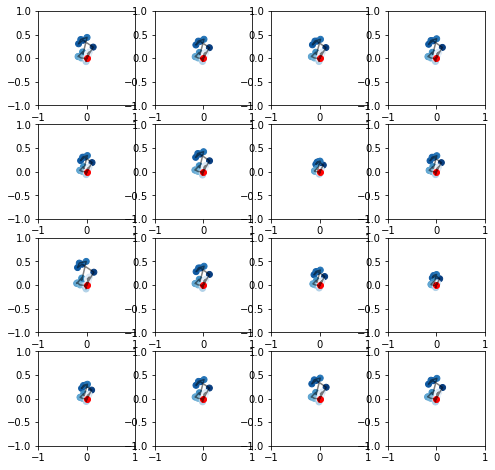

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 0.03553979824750851, Dr : 0.03552392201545911, Df : 0.03554635781508226


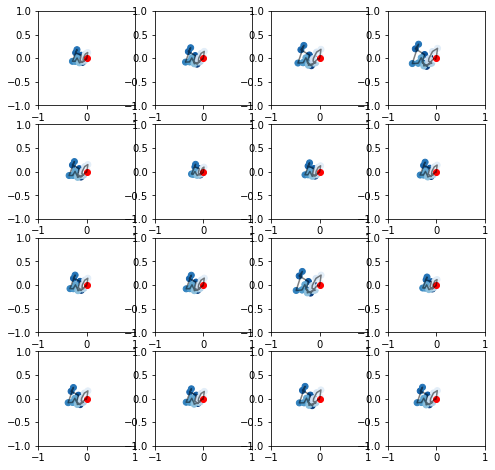

Epoch [4501/5000] -----------------------------------------------------------------------------
G: 0.035510914447980046, Dr : 0.03552303405908438, Df : 0.03554332867646829


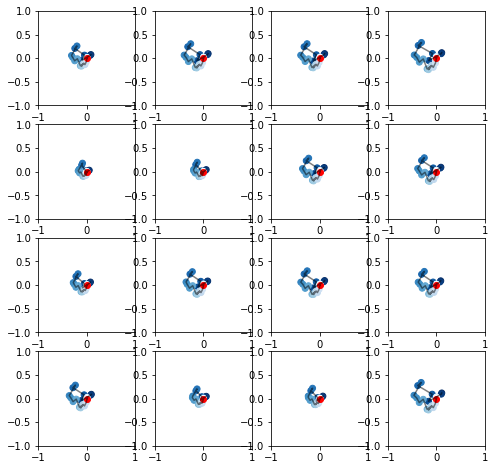

In [27]:
generator = CNNGenerator().to(device)
discriminator = LSTMDiscriminator().to(device)

### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

cnn_lstm = GAN(generator, discriminator, train_loader, device)

# Train the model
nb_epoch = 5000
lr = 0.0002

cnn_lstm.train(nb_epoch, lr, device)

# RESULTS


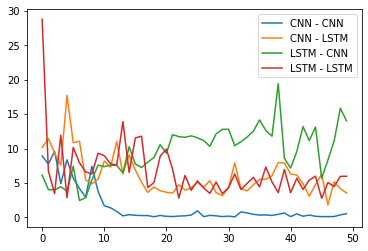

In [31]:
plt.plot(cnn_cnn.score, label = "CNN - CNN")
plt.plot(cnn_lstm.score, label = "CNN - LSTM")
plt.plot(lstm_cnn.score, label = "LSTM - CNN")
plt.plot(lstm_lstm.score, label = "LSTM - LSTM")
plt.legend()